<a href="https://colab.research.google.com/github/rodrigorissettoterra/ai-model-studies/blob/main/008_semantic_search_embeddings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## TF-IDF vs Sentence Embeddings em recuperação de documentos

**Área:** Generative AI / Information Retrieval  
**Tipo de problema:** Busca e recuperação de informação

### Pergunta de estudo

> Uma busca baseada em embeddings consegue recuperar documentos relevantes melhor do que uma busca lexical TF-IDF quando a consulta não usa exatamente as mesmas palavras do documento?

### Abordagens

1. TF-IDF + similaridade de cosseno — baseline lexical;
2. Sentence Transformer + embeddings densos — busca semântica.

### Dataset

Uma amostra de categorias do **20 Newsgroups**.

### Avaliação

Cada consulta possui uma categoria esperada.  
Os resultados serão avaliados com:

- Precision@5;
- MRR (Mean Reciprocal Rank).

Este desenho não substitui um benchmark completo de Information Retrieval, mas fornece uma comparação reproduzível entre recuperação lexical e semântica.


## 1. Configuração do ambiente


In [1]:
# Instala Sentence Transformers.
!pip -q install -U sentence-transformers


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 611.3/611.3 kB 4.9 MB/s eta 0:00:00


In [2]:
# Importações.
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

from sentence_transformers import SentenceTransformer, util

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
TOP_K = 5
DOCS_PER_CATEGORY = 300


## 2. Construção do corpus

Serão usadas seis categorias distintas para criar um corpus com tópicos reconhecíveis.


In [3]:
categories = [
    "comp.graphics",
    "sci.space",
    "rec.sport.baseball",
    "sci.crypt",
    "rec.motorcycles",
    "sci.med",
]

raw_dataset = fetch_20newsgroups(
    subset="test",
    categories=categories,
    remove=("headers", "footers", "quotes"),
    shuffle=True,
    random_state=SEED,
)

corpus_df = pd.DataFrame({
    "text": raw_dataset.data,
    "label": raw_dataset.target,
})

corpus_df["category"] = corpus_df["label"].map(
    dict(enumerate(raw_dataset.target_names))
)

# Remove documentos muito curtos ou vazios.
corpus_df["text"] = corpus_df["text"].str.replace(r"\s+", " ", regex=True).str.strip()
corpus_df = corpus_df[corpus_df["text"].str.len() >= 80].copy()

# Mantém até DOCS_PER_CATEGORY documentos de cada categoria.
corpus_df = (
    corpus_df.groupby("category", group_keys=False)
    .apply(lambda group: group.sample(
        n=min(DOCS_PER_CATEGORY, len(group)),
        random_state=SEED,
    ))
    .reset_index(drop=True)
)

print(f"Documentos no corpus: {len(corpus_df):,}")
display(corpus_df["category"].value_counts().to_frame("Documentos"))


Documentos no corpus: 1,800


/tmp/ipykernel_2438/2479172815.py:34: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: group.sample(


,Documentos
category,
comp.graphics,300
rec.motorcycles,300
rec.sport.baseball,300
sci.crypt,300
sci.med,300
sci.space,300


## 3. Consultas de avaliação

As consultas abaixo são formuladas em linguagem natural e associadas a uma categoria esperada.

Elas não são extraídas diretamente dos documentos, o que torna a comparação mais próxima de uma busca real.


In [4]:
queries = pd.DataFrame([
    {
        "query": "software for rendering three-dimensional images and computer graphics",
        "expected_category": "comp.graphics",
    },
    {
        "query": "spacecraft missions, orbital science and exploration beyond Earth",
        "expected_category": "sci.space",
    },
    {
        "query": "players, pitchers and teams during a baseball season",
        "expected_category": "rec.sport.baseball",
    },
    {
        "query": "encryption, cryptographic keys and protecting private information",
        "expected_category": "sci.crypt",
    },
    {
        "query": "motorcycle engines, riding and maintenance of bikes",
        "expected_category": "rec.motorcycles",
    },
    {
        "query": "medical treatment, disease, symptoms and clinical health questions",
        "expected_category": "sci.med",
    },
])

display(queries)


,query,expected_category
0,software for rendering three-dimensional image...,comp.graphics
1,"spacecraft missions, orbital science and explo...",sci.space
2,"players, pitchers and teams during a baseball ...",rec.sport.baseball
3,"encryption, cryptographic keys and protecting ...",sci.crypt
4,"motorcycle engines, riding and maintenance of ...",rec.motorcycles
5,"medical treatment, disease, symptoms and clini...",sci.med


## 4. Baseline lexical — TF-IDF

TF-IDF representa consultas e documentos em um espaço baseado em termos.

Documentos são ranqueados pela similaridade de cosseno.


In [5]:
tfidf = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    max_features=50_000,
    min_df=2,
)

corpus_tfidf = tfidf.fit_transform(corpus_df["text"])
query_tfidf = tfidf.transform(queries["query"])

tfidf_similarity = cosine_similarity(query_tfidf, corpus_tfidf)


In [6]:
def top_results_from_matrix(similarity_matrix, query_index, top_k=TOP_K):
    indices = np.argsort(similarity_matrix[query_index])[::-1][:top_k]

    result = corpus_df.iloc[indices][["category", "text"]].copy()
    result["score"] = similarity_matrix[query_index][indices]
    return result[["score", "category", "text"]]

# Exemplo.
display(top_results_from_matrix(tfidf_similarity, query_index=0))


,score,category,text
220,0.314841,comp.graphics,Technion - Israel Institute of Technology Depa...
153,0.308353,comp.graphics,EUROPEAN COMPUTER RESEARCH CENTRE Research Pos...
273,0.297914,comp.graphics,"Yes. There are many methods of rendering, rayt..."
0,0.297530,comp.graphics,"Does anyone truely understand the ""INVALID NOR..."
265,0.267393,comp.graphics,Within the next several months I'll be looking...


## 5. Busca semântica — Sentence Transformer

Sentence Transformers converte consultas e documentos em embeddings densos.

Nesta versão da biblioteca, são usados métodos específicos para consulta e documento quando disponíveis.


In [7]:
embedding_model = SentenceTransformer(MODEL_NAME)

corpus_texts = corpus_df["text"].tolist()
query_texts = queries["query"].tolist()

# APIs específicas para Information Retrieval.
if hasattr(embedding_model, "encode_document"):
    corpus_embeddings = embedding_model.encode_document(
        corpus_texts,
        convert_to_tensor=True,
        normalize_embeddings=True,
        show_progress_bar=True,
    )
    query_embeddings = embedding_model.encode_query(
        query_texts,
        convert_to_tensor=True,
        normalize_embeddings=True,
    )
else:
    # Fallback para versões anteriores da biblioteca.
    corpus_embeddings = embedding_model.encode(
        corpus_texts,
        convert_to_tensor=True,
        normalize_embeddings=True,
        show_progress_bar=True,
    )
    query_embeddings = embedding_model.encode(
        query_texts,
        convert_to_tensor=True,
        normalize_embeddings=True,
    )

semantic_hits = util.semantic_search(
    query_embeddings,
    corpus_embeddings,
    top_k=TOP_K,
)


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/57 [00:00<?, ?it/s]

In [8]:
def semantic_results(query_index, top_k=TOP_K):
    hits = semantic_hits[query_index][:top_k]
    indices = [hit["corpus_id"] for hit in hits]
    scores = [hit["score"] for hit in hits]

    result = corpus_df.iloc[indices][["category", "text"]].copy()
    result.insert(0, "score", scores)
    return result.reset_index(drop=True)

# Exemplo para a primeira consulta.
display(semantic_results(query_index=0))


,score,category,text
0,0.567930,comp.graphics,"Yes. There are many methods of rendering, rayt..."
1,0.554429,comp.graphics,Does any one know of a decent quality library ...
2,0.537808,comp.graphics,EUROPEAN COMPUTER RESEARCH CENTRE Research Pos...
3,0.534100,comp.graphics,"Hi I'm new to imaging, and my advisor and I wo..."
4,0.531278,comp.graphics,O I also would like code or algorithms to do t...


## 6. Avaliação: Precision@5 e MRR

### Precision@5

Proporção dos cinco primeiros documentos que pertencem à categoria esperada.

### Reciprocal Rank

Inverso da posição do primeiro documento relevante:

- primeiro lugar → 1.0;
- segundo → 0.5;
- terceiro → 0.333;
- etc.

A média desse valor entre as consultas produz o MRR.


In [9]:
def precision_at_k(categories, expected_category, k=5):
    top = categories[:k]
    return np.mean([category == expected_category for category in top])

def reciprocal_rank(categories, expected_category):
    for rank, category in enumerate(categories, start=1):
        if category == expected_category:
            return 1.0 / rank
    return 0.0

evaluation_rows = []

for query_index, row in queries.iterrows():
    expected = row["expected_category"]

    # TF-IDF: usa um ranking maior para permitir cálculo de RR.
    tfidf_ranked_indices = np.argsort(tfidf_similarity[query_index])[::-1]
    tfidf_categories = corpus_df.iloc[tfidf_ranked_indices]["category"].tolist()

    # Semantic search: calcula um ranking maior para RR.
    expanded_hits = util.semantic_search(
        query_embeddings[query_index:query_index+1],
        corpus_embeddings,
        top_k=min(100, len(corpus_df)),
    )[0]
    semantic_indices = [hit["corpus_id"] for hit in expanded_hits]
    semantic_categories = corpus_df.iloc[semantic_indices]["category"].tolist()

    evaluation_rows.extend([
        {
            "Query": row["query"],
            "Método": "TF-IDF",
            "Precision@5": precision_at_k(tfidf_categories, expected, 5),
            "Reciprocal Rank": reciprocal_rank(tfidf_categories, expected),
        },
        {
            "Query": row["query"],
            "Método": "Sentence Embeddings",
            "Precision@5": precision_at_k(semantic_categories, expected, 5),
            "Reciprocal Rank": reciprocal_rank(semantic_categories, expected),
        },
    ])

evaluation_df = pd.DataFrame(evaluation_rows)

display(evaluation_df)


,Query,Método,Precision@5,Reciprocal Rank
0,software for rendering three-dimensional image...,TF-IDF,1.0,1.0
1,software for rendering three-dimensional image...,Sentence Embeddings,1.0,1.0
2,"spacecraft missions, orbital science and explo...",TF-IDF,1.0,1.0
3,"spacecraft missions, orbital science and explo...",Sentence Embeddings,1.0,1.0
4,"players, pitchers and teams during a baseball ...",TF-IDF,1.0,1.0
5,"players, pitchers and teams during a baseball ...",Sentence Embeddings,1.0,1.0
6,"encryption, cryptographic keys and protecting ...",TF-IDF,1.0,1.0
7,"encryption, cryptographic keys and protecting ...",Sentence Embeddings,1.0,1.0
8,"motorcycle engines, riding and maintenance of ...",TF-IDF,1.0,1.0
9,"motorcycle engines, riding and maintenance of ...",Sentence Embeddings,1.0,1.0


In [10]:
summary = (
    evaluation_df.groupby("Método")[["Precision@5", "Reciprocal Rank"]]
    .mean()
    .rename(columns={"Reciprocal Rank": "MRR"})
)

display(summary.round(4))


,Precision@5,MRR
Método,,
Sentence Embeddings,1.0,1.0
TF-IDF,1.0,1.0


## 7. Comparação qualitativa

Nesta etapa é possível inspecionar os resultados dos dois métodos para a mesma consulta.


In [11]:
QUERY_INDEX = 3

print("Consulta:")
print(queries.loc[QUERY_INDEX, "query"])
print("\nCategoria esperada:")
print(queries.loc[QUERY_INDEX, "expected_category"])

print("\nTF-IDF")
display(top_results_from_matrix(tfidf_similarity, QUERY_INDEX))

print("\nSENTENCE EMBEDDINGS")
display(semantic_results(QUERY_INDEX))


Consulta:
encryption, cryptographic keys and protecting private information

Categoria esperada:
sci.crypt

TF-IDF


,score,category,text
1107,0.229726,sci.crypt,Since the FBI's account of what happened is be...
1097,0.195677,sci.crypt,"From article <67@cyberia.win.net>, by johnston..."
1172,0.174245,sci.crypt,It was implied in the first technical posting ...
1044,0.161391,sci.crypt,The *security* of the system does depend only ...
927,0.159261,sci.crypt,I just joined this group recently and really d...



SENTENCE EMBEDDINGS


,score,category,text
0,0.510894,sci.crypt,"""The security of the system should depend only..."
1,0.482886,sci.crypt,"From article <67@cyberia.win.net>, by johnston..."
2,0.475210,sci.crypt,I just posted this reply to comp.risks (answer...
3,0.475148,sci.crypt,"Dorothy Denning, _Cryptography and Data Securi..."
4,0.470176,sci.crypt,Thanks. Got that from two other sources as wel...


## 8. Visualização do espaço de embeddings

A projeção PCA reduz embeddings para duas dimensões apenas para visualização.

A separação visual não é uma medida formal de qualidade do sistema de busca.


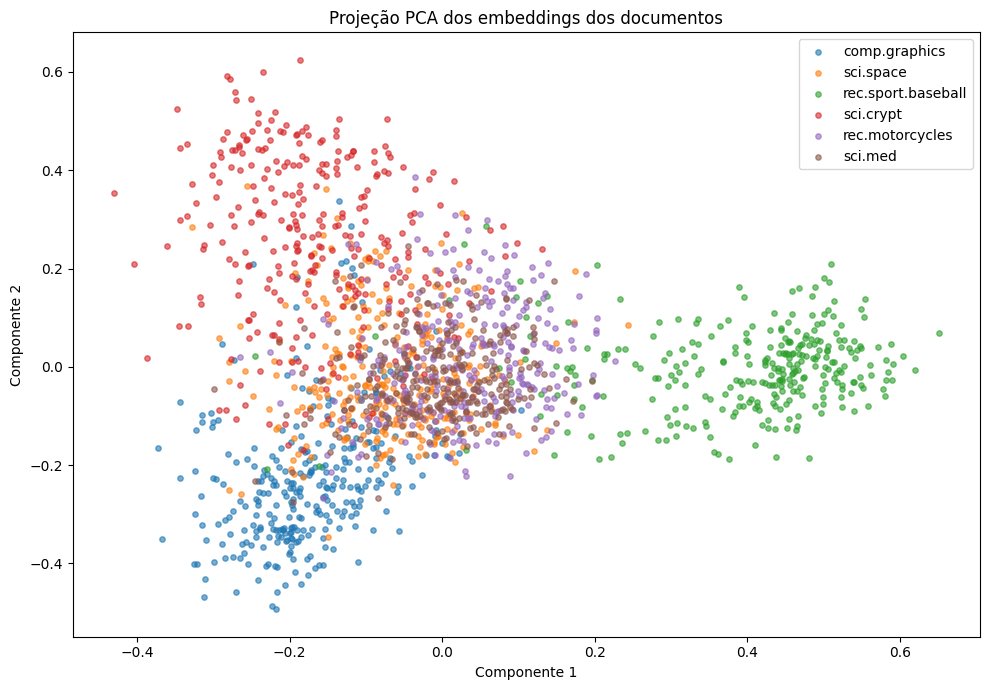

In [12]:
# Converte uma amostra dos embeddings para NumPy.
embedding_array = corpus_embeddings.detach().cpu().numpy()

pca = PCA(n_components=2, random_state=SEED)
projection = pca.fit_transform(embedding_array)

plot_df = corpus_df[["category"]].copy()
plot_df["x"] = projection[:, 0]
plot_df["y"] = projection[:, 1]

plt.figure(figsize=(10, 7))

for category in categories:
    group = plot_df[plot_df["category"] == category]
    plt.scatter(
        group["x"],
        group["y"],
        s=15,
        alpha=0.6,
        label=category,
    )

plt.title("Projeção PCA dos embeddings dos documentos")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.legend()
plt.tight_layout()
plt.show()


## 9. Conclusão


In [13]:
from IPython.display import Markdown, display

tfidf_p5 = summary.loc["TF-IDF", "Precision@5"]
semantic_p5 = summary.loc["Sentence Embeddings", "Precision@5"]

tfidf_mrr = summary.loc["TF-IDF", "MRR"]
semantic_mrr = summary.loc["Sentence Embeddings", "MRR"]

best_p5 = summary["Precision@5"].idxmax()
best_mrr = summary["MRR"].idxmax()

conclusion = f'''
### Síntese dos resultados

**Precision@5 médio**

- TF-IDF: **{tfidf_p5:.3f}**
- Sentence Embeddings: **{semantic_p5:.3f}**

**MRR**

- TF-IDF: **{tfidf_mrr:.3f}**
- Sentence Embeddings: **{semantic_mrr:.3f}**

O melhor método em Precision@5 foi **{best_p5}** e o melhor em MRR foi **{best_mrr}**.

### Interpretação

A busca lexical depende fortemente da coincidência de termos entre consulta e documento.
Embeddings densos procuram representar proximidade de significado, o que pode recuperar documentos relevantes mesmo quando consulta e texto utilizam vocabulário diferente.

### Limitações

- as categorias do 20 Newsgroups funcionam como uma aproximação de relevância;
- uma categoria ampla não garante que cada documento seja realmente relevante para toda consulta;
- há apenas seis consultas;
- não foram avaliados modelos de reranking;
- latência, memória e custo não foram medidos.

### Próximos experimentos

1. ampliar o conjunto de consultas e julgamentos de relevância;
2. medir Recall@K e nDCG;
3. comparar diferentes modelos de embeddings;
4. adicionar reranking com CrossEncoder;
5. indexar embeddings em FAISS ou banco vetorial;
6. utilizar esta busca como base do próximo estudo de RAG.
'''

display(Markdown(conclusion))



### Síntese dos resultados

**Precision@5 médio**

- TF-IDF: **1.000**
- Sentence Embeddings: **1.000**

**MRR**

- TF-IDF: **1.000**
- Sentence Embeddings: **1.000**

O melhor método em Precision@5 foi **Sentence Embeddings** e o melhor em MRR foi **Sentence Embeddings**.

### Interpretação

A busca lexical depende fortemente da coincidência de termos entre consulta e documento.
Embeddings densos procuram representar proximidade de significado, o que pode recuperar documentos relevantes mesmo quando consulta e texto utilizam vocabulário diferente.

### Limitações

- as categorias do 20 Newsgroups funcionam como uma aproximação de relevância;
- uma categoria ampla não garante que cada documento seja realmente relevante para toda consulta;
- há apenas seis consultas;
- não foram avaliados modelos de reranking;
- latência, memória e custo não foram medidos.

### Próximos experimentos

1. ampliar o conjunto de consultas e julgamentos de relevância;
2. medir Recall@K e nDCG;
3. comparar diferentes modelos de embeddings;
4. adicionar reranking com CrossEncoder;
5. indexar embeddings em FAISS ou banco vetorial;
6. utilizar esta busca como base do próximo estudo de RAG.


## Referências

- 20 Newsgroups — scikit-learn
- Sentence Transformers — Semantic Search
- `sentence-transformers/all-MiniLM-L6-v2`
